# Exploratory Data Analysis of Global Power Plant Country Summaries

**Course:** Big Data Analysis — Week 2  
**Student name:** مجتبى محمد حسين  
**Program:** Master of Information Management Technologies (ماجستير تقنيات إدارة المعلومات)

## A. Introduction and Questions

This analysis examines the supplied country summary of the Global Power Plant Database. Each row represents a country or territory, not an individual plant. The analysis describes the supplied snapshot and its coverage; it does not estimate current worldwide electricity production.

The input is `global_power_plant_database_country_summary.csv`, copied unchanged to `dataset.csv`. The upstream project is the [World Resources Institute Global Power Plant Database](https://github.com/wri/global-power-plant-database). The supplied file does not identify its release or download date, so no release is assumed. WRI publishes the database under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). This project retains attribution and makes no changes to the distributed CSV.

### Analysis questions

1. How much of the country list has recorded plants, and what data quality issues affect analysis?
2. Which countries have the most recorded capacity, and how concentrated is that capacity?
3. How are country capacities distributed, and which fuel categories are most represented?
4. How strongly are plant counts and fuel diversity associated with total capacity?
5. How does annual generation reporting coverage vary over years and across country size groups?

### Important variable definitions

| Variable | Meaning and units |
| --- | --- |
| `iso_code`, `country` | Country/territory identifiers; excluded from correlation analysis. |
| `count` | Number of recorded plants. |
| `total_capacity_gw` | Total recorded electrical capacity in gigawatts (GW). |
| `max_capacity_mw` | Largest recorded plant capacity in megawatts (MW). |
| `count_distinct_fuel` | Number of distinct listed fuel categories. |
| `count_fuel_*`, `capacity_gw_fuel_*` | Plant count and capacity associated with a listed fuel, including secondary fuels; categories can overlap. |
| `count_distinct_name/owner/source` | Counts of distinct non-missing names, owners, and sources. |
| `count_null_*` | Counts of missing fields in underlying plant records, not missing cells in this CSV. |
| `count_generation_gwh_YYYY` | Number of plants with reported generation in that year; these are counts, not GWh amounts. |
| `count_estimated_generation_gwh` | Number with the summary's estimated-generation field available. |
| `count_generation_data_source` | Number with generation-source information. |
| `count_wepp_id`, `capacity_gw_wepp_id` | Count and capacity of records linked to a WEPP identifier. |

The [upstream summary code](https://github.com/wri/global-power-plant-database/blob/master/utils/database_country_summary.py) defines these aggregations. Its `count_null_generation_gwh_all` checks 2015–2019 and an estimate field; it is not a reliable measure of missing *reported* generation in every year. We use explicit year-specific counts instead. There are no row-level dates to parse. Year suffixes describe reporting fields.

## B. Load and Inspect the Data

Load the original CSV using a relative path. Show a readable sample of important fields, then inspect every column and its type. No network connection is needed to run the analysis.

In [1]:
from pathlib import Path
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', palette='colorblind', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.max_rows', 70)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

raw = pd.read_csv('dataset.csv')
print(f'Rows: {raw.shape[0]} | Columns: {raw.shape[1]}')
print('Python:', platform.python_version())
print('Package versions:', {'pandas': pd.__version__, 'numpy': np.__version__, 'matplotlib': matplotlib.__version__, 'seaborn': sns.__version__})
print('CSV SHA-256:', hashlib.sha256(Path('dataset.csv').read_bytes()).hexdigest())
display(raw[['iso_code', 'country', 'count', 'total_capacity_gw', 'max_capacity_mw', 'count_distinct_fuel']].head(8))

Rows: 212 | Columns: 61
Python: 3.12.10
Package versions: {'pandas': '3.0.5', 'numpy': '2.5.2', 'matplotlib': '3.11.2', 'seaborn': '0.13.2'}
CSV SHA-256: 63ae234463eae135c97858aa928ef17eb098fa3be53b89d6689aeb5cd1507e07


,iso_code,country,count,total_capacity_gw,max_capacity_mw,count_distinct_fuel
0,AFG,Afghanistan,9,0.301,100.000,3.000
1,ALB,Albania,8,1.529,600.000,2.000
2,DZA,Algeria,59,15.874,"1,200.000",4.000
3,ASM,American Samoa,0,NaN,NaN,NaN
4,AGO,Angola,14,1.071,520.000,3.000
5,ATA,Antarctica,2,0.008,6.600,2.000
6,ATG,Antigua and Barbuda,0,NaN,NaN,NaN
7,ARG,Argentina,236,32.913,"1,982.200",8.000


The table includes both countries with recorded plants and entries with zero recorded plants. A zero count describes database coverage and does not establish that the country has no electricity infrastructure.

In [2]:
raw.info()
schema = pd.DataFrame({'column': raw.columns, 'dtype': raw.dtypes.astype(str).values,
                       'non_missing': raw.notna().sum().values,
                       'missing': raw.isna().sum().values})
display(schema)

<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 61 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   iso_code                          212 non-null    str    
 1   country                           212 non-null    str    
 2   count                             212 non-null    int64  
 3   total_capacity_gw                 167 non-null    float64
 4   max_capacity_mw                   167 non-null    float64
 5   count_distinct_fuel               167 non-null    float64
 6   count_distinct_name               167 non-null    float64
 7   count_distinct_owner              167 non-null    float64
 8   count_distinct_source             167 non-null    float64
 9   count_fuel_coal                   167 non-null    float64
 10  capacity_gw_fuel_coal             167 non-null    float64
 11  count_fuel_gas                    167 non-null    float64
 12  capacity_gw_fuel_ga

,column,dtype,non_missing,missing
0,iso_code,str,212,0
1,country,str,212,0
2,count,int64,212,0
3,total_capacity_gw,float64,167,45
4,max_capacity_mw,float64,167,45
5,count_distinct_fuel,float64,167,45
6,count_distinct_name,float64,167,45
7,count_distinct_owner,float64,167,45
8,count_distinct_source,float64,167,45
9,count_fuel_coal,float64,167,45


The identifier columns are textual and all other columns are numerical. Count fields with missing entries load as floating-point numbers; they will be converted to nullable integers after checking that their observed values are whole numbers. The missingness audit below distinguishes absent country summaries from missing underlying plant attributes.

## C. Check and Prepare the Data

### Missing values and duplicate records

In [3]:
missing = pd.DataFrame({'missing_cells': raw.isna().sum(), 'missing_pct': raw.isna().mean() * 100})
display(missing.loc[missing.missing_cells > 0])
print('Exact duplicate rows:', raw.duplicated().sum())
print('Duplicate ISO codes:', raw.iso_code.duplicated().sum())
print('Duplicate country names:', raw.country.duplicated().sum())
uncovered = raw.loc[raw['count'].eq(0)]
covered = raw.loc[raw['count'].gt(0)]
print('Countries/territories without recorded plants:', len(uncovered))
print('Missing numerical cells among countries with recorded plants:', covered.iloc[:, 2:].isna().sum().sum())
display(uncovered[['iso_code', 'country', 'count']])

,missing_cells,missing_pct
total_capacity_gw,45,21.226
max_capacity_mw,45,21.226
count_distinct_fuel,45,21.226
count_distinct_name,45,21.226
count_distinct_owner,45,21.226
count_distinct_source,45,21.226
count_fuel_coal,45,21.226
capacity_gw_fuel_coal,45,21.226
count_fuel_gas,45,21.226
capacity_gw_fuel_gas,45,21.226


Exact duplicate rows: 0
Duplicate ISO codes: 0
Duplicate country names: 0
Countries/territories without recorded plants: 45
Missing numerical cells among countries with recorded plants: 0


,iso_code,country,count
3,ASM,American Samoa,0
6,ATG,Antigua and Barbuda,0
9,ABW,Aruba,0
13,BHS,Bahamas,0
16,BRB,Barbados,0
19,BLZ,Belize,0
21,BMU,Bermuda,0
27,VGB,British Virgin Islands,0
36,CYM,Cayman Islands,0
38,TCD,Chad,0


All 45 zero-record entries have missing summary metrics. All 167 entries with recorded plants have complete numerical summaries. No exact duplicates or duplicate country identifiers are present. We preserve the raw table and its missing cells, avoid imputing country capacities, and use only countries with recorded plants for capacity and reporting comparisons. No duplicate removal is needed.

In [4]:
clean = raw.copy()
for col in ['iso_code', 'country']:
    clean[col] = clean[col].astype('string').str.strip()
numeric_cols = clean.columns.difference(['iso_code', 'country'])
for col in numeric_cols:
    clean[col] = pd.to_numeric(clean[col], errors='raise')
assert clean[numeric_cols].ge(0).where(clean[numeric_cols].notna(), True).all().all(), 'Negative values require investigation'
count_cols = [c for c in clean if c == 'count' or c.startswith('count_')]
for col in count_cols:
    assert np.allclose(clean[col].dropna() % 1, 0), f'Non-integer count: {col}'
    clean[col] = clean[col].astype('Int64')
assert clean.iso_code.is_unique and clean.country.is_unique
analysis = clean.loc[clean['count'].gt(0) & clean.total_capacity_gw.notna()].copy()
assert analysis.total_capacity_gw.gt(0).all()
assert analysis[count_cols].le(analysis['count'], axis=0).all().all()
assert (analysis.max_capacity_mw <= analysis.total_capacity_gw * 1000 + 1e-6).all()

audit = pd.DataFrame({'stage': ['Original data', 'Typed data retained', 'Capacity analysis subset'],
                      'rows': [len(raw), len(clean), len(analysis)],
                      'columns': [raw.shape[1], clean.shape[1], analysis.shape[1]]})
display(audit)

,stage,rows,columns
0,Original data,212,61
1,Typed data retained,212,61
2,Capacity analysis subset,167,61


Typing and whitespace normalization retain all 212 rows and 61 original columns. The capacity-analysis subset contains 167 rows; the 45 exclusions are limited to this subset and are justified by absent plant records. The checks confirm non-negative metrics, whole-number counts, unique identifiers, and consistent maximum versus total capacity. Large values are retained because they can represent genuinely large recorded systems.

### Fuel overlap and derived comparison measures

In [5]:
fuel_capacity_cols = [c for c in analysis if c.startswith('capacity_gw_fuel_')]
fuel_sum = analysis[fuel_capacity_cols].sum(axis=1)
overlap = fuel_sum > analysis.total_capacity_gw + 1e-6
display(analysis.loc[overlap, ['country', 'total_capacity_gw']]
        .assign(sum_fuel_capacity_gw=fuel_sum[overlap], excess_gw=(fuel_sum-analysis.total_capacity_gw)[overlap])
        .sort_values('excess_gw', ascending=False).head(10))
print('Countries with overlapping fuel capacity:', int(overlap.sum()))

analysis['mean_recorded_plant_mw'] = analysis.total_capacity_gw * 1000 / analysis['count']
analysis['generation_2019_coverage_pct'] = 100 * analysis.count_generation_gwh_2019 / analysis['count']
analysis['capacity_share_pct'] = 100 * analysis.total_capacity_gw / analysis.total_capacity_gw.sum()
analysis['size_group'] = pd.cut(analysis['count'].astype(float), bins=[0, 10, 100, np.inf],
                              labels=['1–10 plants', '11–100 plants', '101+ plants'])
print('Derived fields added:', analysis.shape[1] - clean.shape[1])

,country,total_capacity_gw,sum_fuel_capacity_gw,excess_gw
202,United States of America,"1,204.638","1,740.730",536.092
88,India,316.089,519.322,203.233
157,Russia,228.220,289.023,60.803
200,United Arab Emirates,30.327,59.814,29.487
166,Saudi Arabia,84.342,108.388,24.047
7,Argentina,32.913,50.600,17.687
96,Japan,215.366,233.040,17.674
102,Kuwait,17.829,29.253,11.424
91,Iraq,18.161,25.337,7.176
151,Poland,37.902,44.169,6.267


Countries with overlapping fuel capacity: 36
Derived fields added: 4


Fuel-associated capacities exceed country totals in 36 cases, consistent with overlapping fuel categories. These are not removed as errors. Fuel plots therefore use separate bars, not a pie chart or an additive energy mix. Mean recorded plant capacity equals country capacity × 1,000 ÷ recorded plant count. Reporting coverage equals plants reporting in 2019 ÷ recorded plants × 100. The three plant-count groups are descriptive, predeclared ranges rather than inferred economic classifications.

## D. Describe and Visualize the Data

### Numerical summaries

In [6]:
summary_cols = ['count', 'total_capacity_gw', 'max_capacity_mw', 'count_distinct_fuel',
                'mean_recorded_plant_mw', 'generation_2019_coverage_pct']
summary = analysis[summary_cols].astype(float).agg(['count', 'mean', 'median', 'var', 'std', 'min', 'max']).T
display(summary)
total_plants = int(analysis['count'].sum())
total_capacity = analysis.total_capacity_gw.sum()
print(f'Recorded plants: {total_plants:,}; recorded capacity: {total_capacity:,.3f} GW')
print(f'Plant-weighted mean capacity: {total_capacity * 1000 / total_plants:,.2f} MW')

,count,mean,median,var,std,min,max
count,167.000,209.198,16.000,"804,453.413",896.913,1.000,"9,833.000"
total_capacity_gw,167.000,34.174,3.720,"21,709.414",147.341,0.003,"1,415.067"
max_capacity_mw,167.000,"1,809.844","1,021.000","6,409,176.870","2,531.635",3.000,"22,500.000"
count_distinct_fuel,167.000,4.251,3.000,7.057,2.656,1.000,14.000
mean_recorded_plant_mw,167.000,270.708,155.222,"119,517.240",345.713,3.000,"2,920.000"
generation_2019_coverage_pct,167.000,0.588,0.000,57.780,7.601,0.000,98.230


Recorded plants: 34,936; recorded capacity: 5,706.975 GW
Plant-weighted mean capacity: 163.36 MW


The summary gives each country equal weight; sample variance and standard deviation use `ddof=1`. Recorded capacity totals 5,706.975 GW across 34,936 plants. Country capacity has a mean of 34.174 GW but a median of only 3.720 GW, indicating strong right skew. The separately reported plant-weighted mean must not be confused with the mean of country-level plant averages. Capacity measures installed power; it is not annual energy generated.

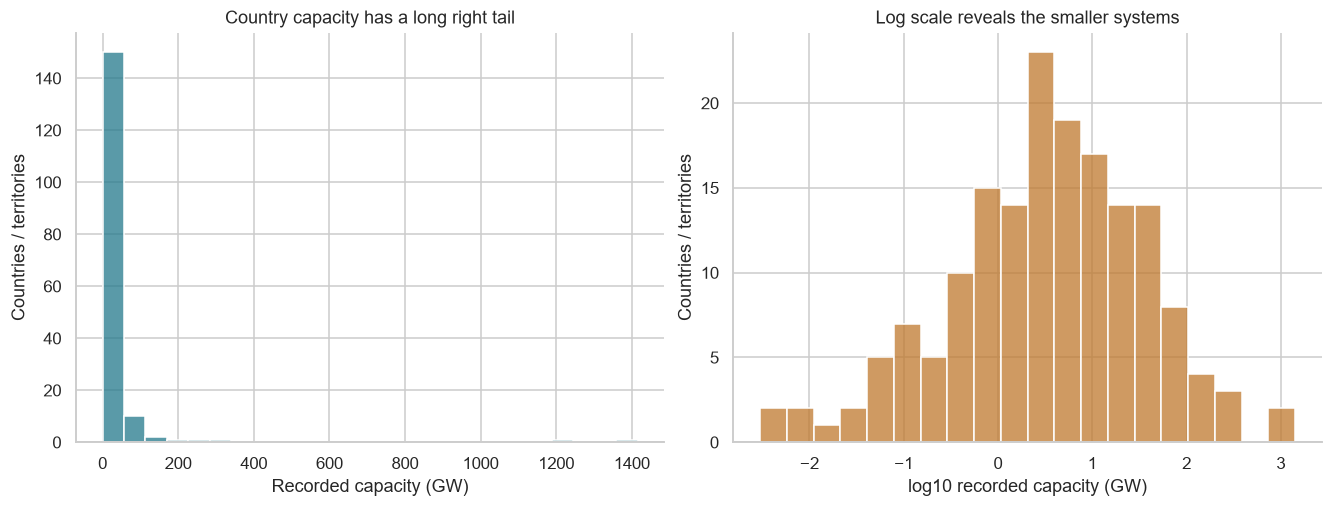

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
sns.histplot(data=analysis, x='total_capacity_gw', bins=25, ax=axes[0], color='#23788b')
axes[0].set(title='Country capacity has a long right tail', xlabel='Recorded capacity (GW)', ylabel='Countries / territories')
sns.histplot(x=np.log10(analysis.total_capacity_gw.astype(float)), bins=20, ax=axes[1], color='#bf792d')
axes[1].set(title='Log scale reveals the smaller systems', xlabel='log10 recorded capacity (GW)', ylabel='Countries / territories')
plt.show()

Most country summaries lie at the low end of the raw scale, while a few very large systems extend the right tail. The log10 transformation spreads out smaller systems without removing large observations. A one-unit difference on the transformed axis represents a tenfold difference in capacity.

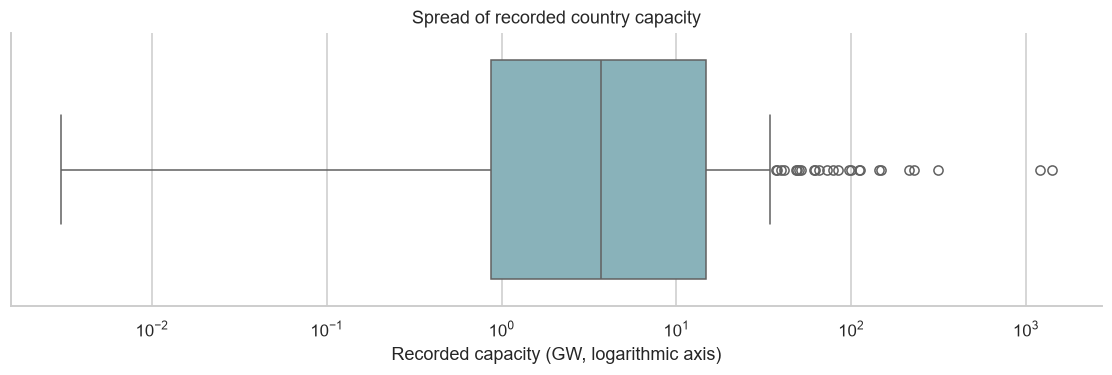

Upper 1.5-IQR threshold on original values: 35.455 GW
Countries above that threshold: 25


In [8]:
fig, ax = plt.subplots(figsize=(10, 3.3), layout='constrained')
sns.boxplot(x=analysis.total_capacity_gw, ax=ax, color='#81b8c2')
ax.set_xscale('log')
ax.set(title='Spread of recorded country capacity', xlabel='Recorded capacity (GW, logarithmic axis)', ylabel='')
plt.show()
q1, q3 = analysis.total_capacity_gw.quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
print(f'Upper 1.5-IQR threshold on original values: {upper:.3f} GW')
print('Countries above that threshold:', int(analysis.total_capacity_gw.gt(upper).sum()))

The box plot calculates quartiles and outlier fences on original GW values, then displays them on a logarithmic axis. Points beyond the fence are statistical flags, not proof of incorrect data. They remain in every analysis; country size and database coverage can legitimately create large differences.

,country,count,total_capacity_gw,capacity_share_pct
40,China,4235,"1,415.067",24.795
202,United States of America,9833,"1,204.638",21.108
88,India,1589,316.089,5.539
157,Russia,545,228.220,3.999
96,Japan,522,215.366,3.774
26,Brazil,2360,147.589,2.586
34,Canada,1159,143.579,2.516
72,Germany,1309,112.040,1.963
66,France,2155,110.616,1.938
177,South Korea,132,99.473,1.743


Top-ten share of dataset capacity: 69.96%


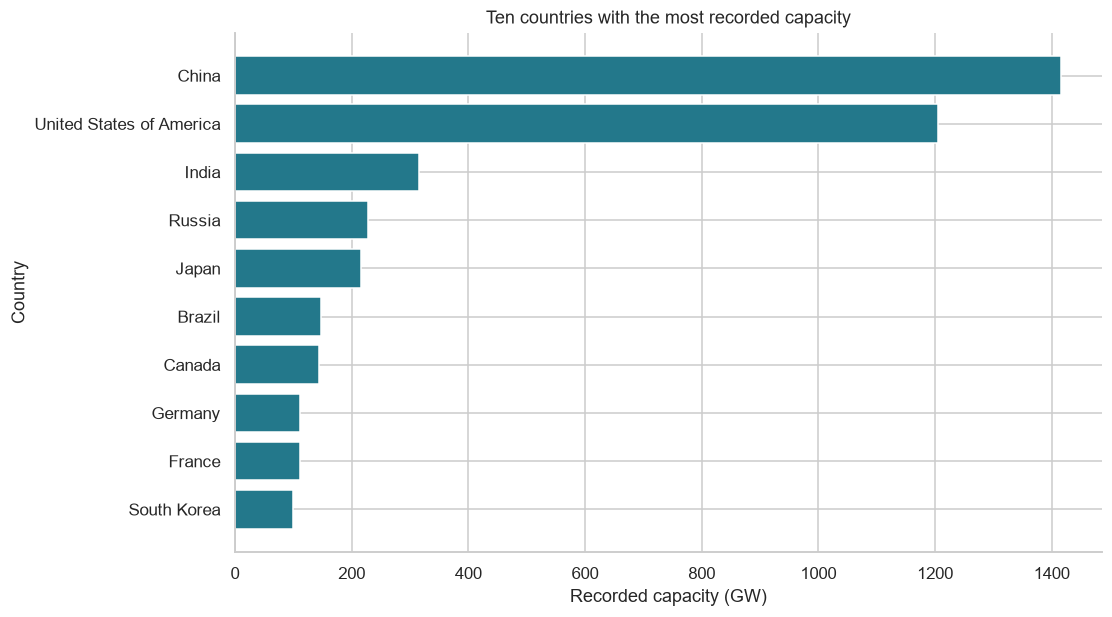

In [9]:
top = analysis.nlargest(10, 'total_capacity_gw')
display(top[['country', 'count', 'total_capacity_gw', 'capacity_share_pct']])
top_share = top.total_capacity_gw.sum() / total_capacity * 100
fig, ax = plt.subplots(figsize=(10, 5.5), layout='constrained')
plot_top = top.sort_values('total_capacity_gw')
ax.barh(plot_top.country, plot_top.total_capacity_gw, color='#23788b')
ax.set(title='Ten countries with the most recorded capacity', xlabel='Recorded capacity (GW)', ylabel='Country')
print(f'Top-ten share of dataset capacity: {top_share:.2f}%')
plt.show()

China leads recorded capacity at 1,415.067 GW, followed by the United States at 1,204.638 GW. The United States has more recorded plants (9,833 versus China's 4,235), so plant count and capacity rank are not interchangeable. Shares use the dataset's total capacity as denominator and should not be interpreted as verified shares of present-day worldwide capacity.

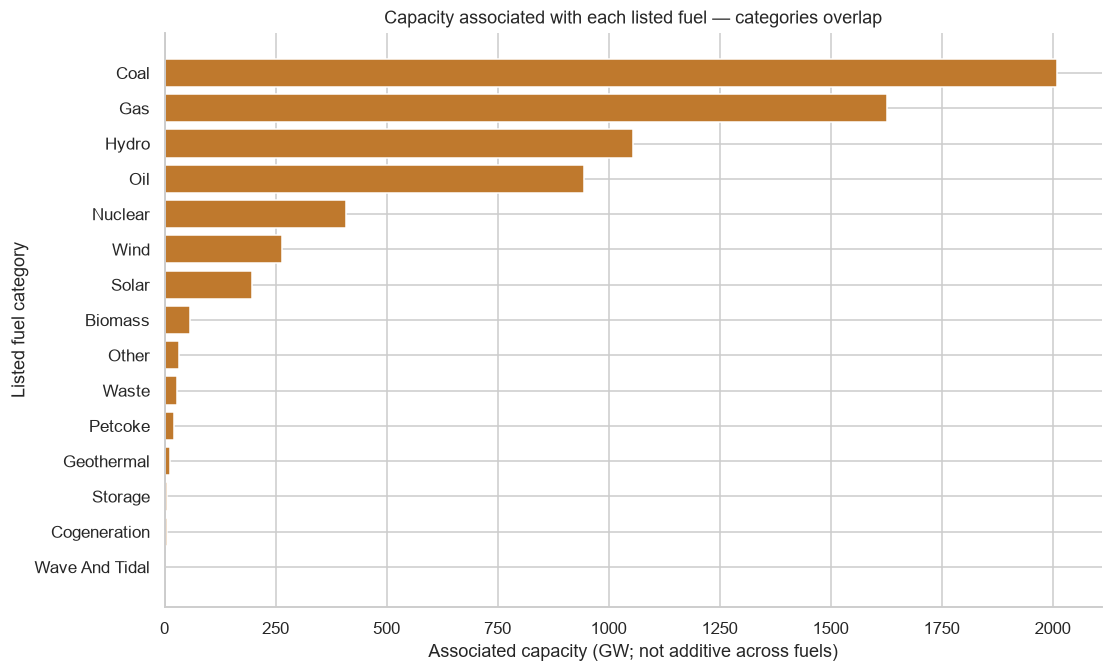

Largest associated fuel capacity: Coal 2,010.27 GW


In [10]:
fuel_totals = analysis[fuel_capacity_cols].sum().sort_values(ascending=True)
fuel_labels = [c.replace('capacity_gw_fuel_', '').replace('_', ' ').title() for c in fuel_totals.index]
fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')
ax.barh(fuel_labels, fuel_totals, color='#bf792d')
ax.set(title='Capacity associated with each listed fuel — categories overlap',
       xlabel='Associated capacity (GW; not additive across fuels)', ylabel='Listed fuel category')
plt.show()
print('Largest associated fuel capacity:', fuel_labels[-1], f'{fuel_totals.iloc[-1]:,.2f} GW')

Each bar counts full plant capacity where that fuel is listed. A multi-fuel plant can contribute to multiple bars. The leading bar indicates the largest fuel-associated capacity, not actual fuel consumption or generation. Adding renewable categories would also risk double counting, so no renewable-share estimate is constructed from these overlapping summaries.

## E. Explore Relationships

### Plant count and total capacity

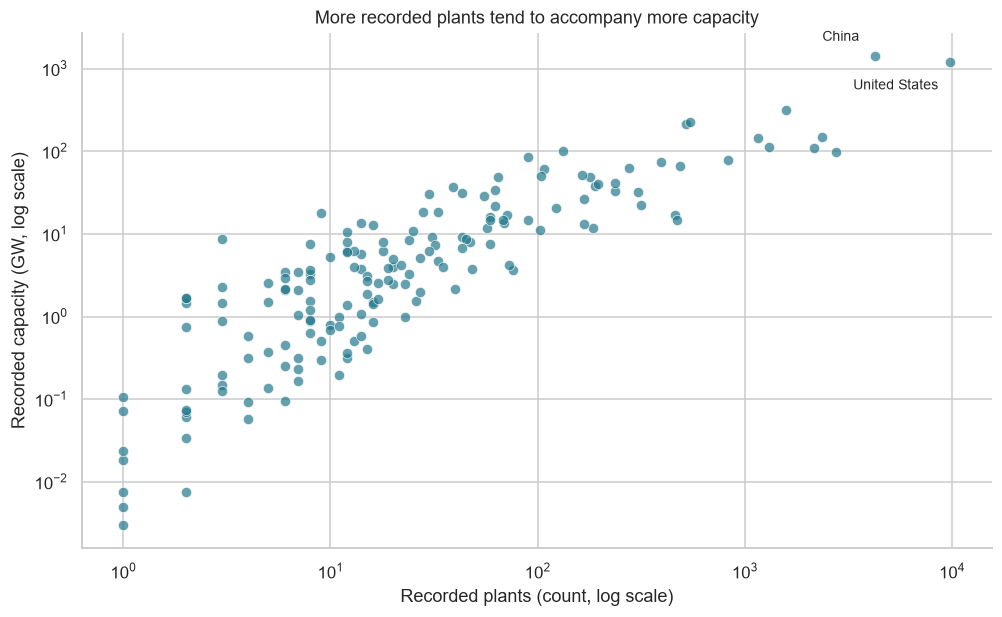

Raw Pearson r = 0.859; Spearman rho = 0.868; log10 Pearson r = 0.862; n = 167
Pearson excluding the top two capacity countries (sensitivity only): 0.696


In [11]:
x = analysis['count'].astype(float)
y = analysis.total_capacity_gw.astype(float)
pearson = x.corr(y)
spearman = x.rank().corr(y.rank())
log_pearson = np.log10(x).corr(np.log10(y))
fig, ax = plt.subplots(figsize=(9, 5.5), layout='constrained')
sns.scatterplot(x=x, y=y, ax=ax, s=45, alpha=0.7, color='#23788b')
ax.set(xscale='log', yscale='log', title='More recorded plants tend to accompany more capacity',
       xlabel='Recorded plants (count, log scale)', ylabel='Recorded capacity (GW, log scale)')
for _, row in analysis.nlargest(2, 'total_capacity_gw').iterrows():
    label = 'United States' if row.iso_code == 'USA' else row.country
    offset = (-10, 10) if row.iso_code == 'CHN' else (-8, -18)
    ax.annotate(label, (row['count'], row.total_capacity_gw), xytext=offset,
                textcoords='offset points', ha='right', fontsize=9)
plt.show()
print(f'Raw Pearson r = {pearson:.3f}; Spearman rho = {spearman:.3f}; log10 Pearson r = {log_pearson:.3f}; n = {len(analysis)}')
without_top2 = analysis.drop(analysis.nlargest(2, 'total_capacity_gw').index)
print('Pearson excluding the top two capacity countries (sensitivity only):',
      round(without_top2['count'].astype(float).corr(without_top2.total_capacity_gw), 3))

The plot compares country totals with a logarithmic display. Raw Pearson correlation captures linear association, Spearman correlation uses ranks, and log Pearson describes multiplicative scaling. The sensitivity result shows how the largest systems influence the raw relationship; those systems remain in the main sample. Plant count contributes mechanically to total capacity, so this association is not causal evidence.

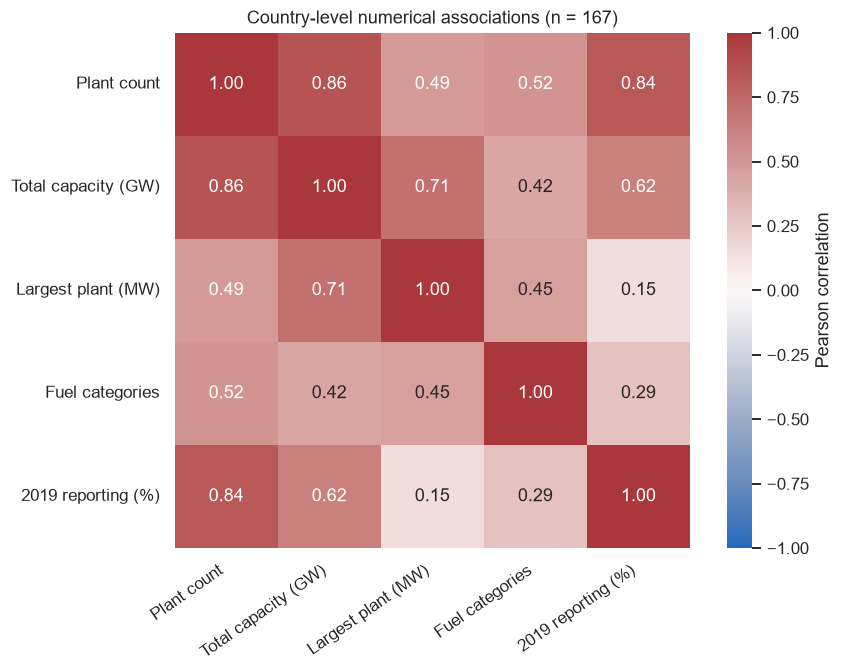

Fuel category count versus total capacity: Pearson r = 0.425


In [12]:
corr_cols = ['count', 'total_capacity_gw', 'max_capacity_mw', 'count_distinct_fuel', 'generation_2019_coverage_pct']
labels = ['Plant count', 'Total capacity (GW)', 'Largest plant (MW)', 'Fuel categories', '2019 reporting (%)']
corr = analysis[corr_cols].astype(float).corr(method='pearson')
fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')
sns.heatmap(corr, annot=True, fmt='.2f', vmin=-1, vmax=1, center=0, cmap='vlag', square=True,
            xticklabels=labels, yticklabels=labels, ax=ax, cbar_kws={'label': 'Pearson correlation'})
ax.set_title(f'Country-level numerical associations (n = {len(analysis)})')
ax.tick_params(axis='x', rotation=35)
for label in ax.get_xticklabels():
    label.set_ha('right')
plt.show()
fuel_r = float(corr.loc['count_distinct_fuel', 'total_capacity_gw'])
print(f'Fuel category count versus total capacity: Pearson r = {fuel_r:.3f}')

Only meaningful numerical measures enter the heatmap. ISO identifiers, country names, and group labels are excluded. Larger systems may include more fuel types, but geography, coverage, and economic scale are unmeasured factors. Reporting percentage is a data-availability metric, not plant efficiency or utilization. Correlations between aggregates cannot establish plant-level relationships.

### Generation reporting coverage by country size

,countries,plants,plants_reporting_2019,median_country_coverage_pct,plant_weighted_coverage_pct
size_group,,,,,
1–10 plants,60,297,0,0.000,0.000
11–100 plants,75,2353,0,0.000,0.000
101+ plants,32,32286,9659,0.000,29.917


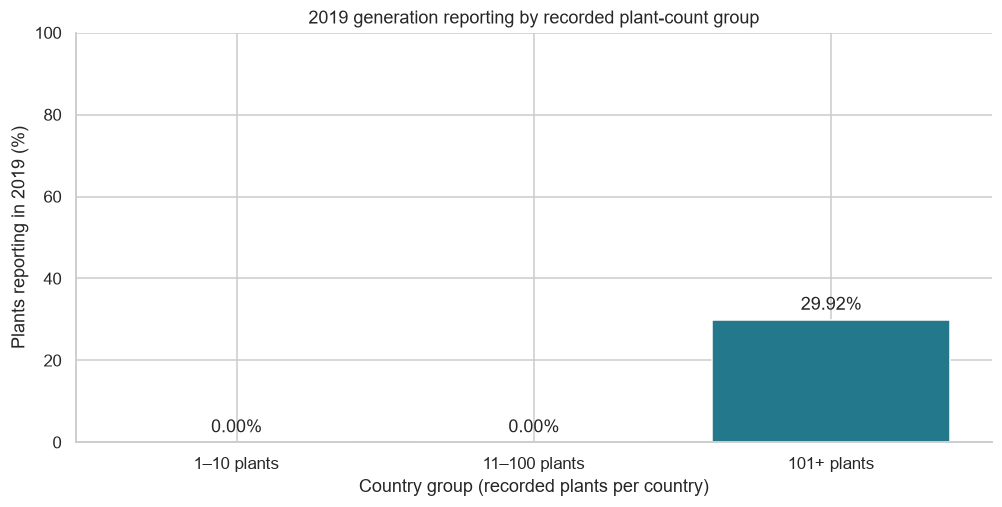

In [13]:
groups = analysis.groupby('size_group', observed=True).agg(
    countries=('country', 'size'), plants=('count', 'sum'),
    plants_reporting_2019=('count_generation_gwh_2019', 'sum'),
    median_country_coverage_pct=('generation_2019_coverage_pct', 'median'))
groups['plant_weighted_coverage_pct'] = 100 * groups.plants_reporting_2019 / groups.plants
display(groups)
fig, ax = plt.subplots(figsize=(9, 4.5), layout='constrained')
bars = ax.bar(groups.index.astype(str), groups.plant_weighted_coverage_pct.astype(float), color='#23788b')
ax.bar_label(bars, labels=[f'{v:.2f}%' for v in groups.plant_weighted_coverage_pct], padding=4)
ax.set(ylim=(0, 100), title='2019 generation reporting by recorded plant-count group',
       xlabel='Country group (recorded plants per country)', ylabel='Plants reporting in 2019 (%)')
plt.show()

Group sizes differ, so the bars compare reporting percentages rather than raw reporting counts. The denominator in each bar is all recorded plants in that group. The table also gives the median country percentage, which answers a different question by weighting countries equally. Differences may reflect data collection practices rather than physical differences between energy systems.

,year,plants_reporting,coverage_pct
0,2013,6417,18.368
1,2014,7226,20.684
2,2015,8203,23.480
3,2016,9144,26.174
4,2017,9500,27.193
5,2018,9637,27.585
6,2019,9659,27.648


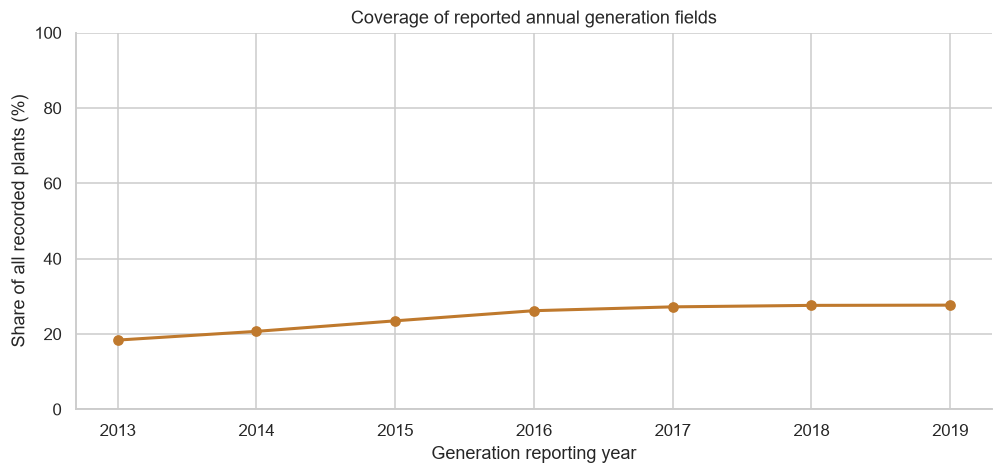

In [14]:
year_cols = [f'count_generation_gwh_{year}' for year in range(2013, 2020)]
yearly = pd.DataFrame({'year': range(2013, 2020),
                      'plants_reporting': [int(analysis[c].sum()) for c in year_cols]})
yearly['coverage_pct'] = yearly.plants_reporting / total_plants * 100
display(yearly)
fig, ax = plt.subplots(figsize=(9, 4.2), layout='constrained')
ax.plot(yearly.year, yearly.coverage_pct, marker='o', color='#bf792d', linewidth=2)
ax.set(ylim=(0, 100), xticks=yearly.year, title='Coverage of reported annual generation fields',
       xlabel='Generation reporting year', ylabel='Share of all recorded plants (%)')
plt.show()

Reporting counts rise from 6,417 in 2013 to 9,659 in 2019. The denominator is the same snapshot total of 34,936 plants for every year, not the number operating in each historical year. This measures field availability in this file; it does not show growth in electricity generation, and plants reporting in multiple years must not be added as distinct plants.

## F. Draw Conclusions

In [15]:
lead = analysis.loc[analysis.total_capacity_gw.idxmax()]
fuel_lead = fuel_labels[-1]
best_group = groups.plant_weighted_coverage_pct.idxmax()
conclusion = f"""
1. **Coverage and quality:** {len(raw)} country/territory entries include {len(analysis)} with recorded plants and {len(uncovered)} with no recorded plants. There are no duplicate rows or country identifiers. Missing summary cells are confined to the zero-record entries.
2. **Capacity concentration:** {total_plants:,} recorded plants total {total_capacity:,.3f} GW. {lead.country} leads at {lead.total_capacity_gw:,.3f} GW. The top ten account for {top_share:.2f}% of dataset capacity.
3. **Distribution and fuels:** Mean country capacity is {analysis.total_capacity_gw.mean():.3f} GW versus a median of {analysis.total_capacity_gw.median():.3f} GW. {fuel_lead} has the highest fuel-associated capacity. Overlap occurs in {int(overlap.sum())} country summaries, so fuel categories cannot be added into a mutually exclusive mix.
4. **Relationships:** Plant count and capacity have Pearson r = {pearson:.3f}, Spearman rho = {spearman:.3f}, and log10 Pearson r = {log_pearson:.3f}. Fuel diversity and total capacity have Pearson r = {fuel_r:.3f}. These descriptive associations do not establish causation.
5. **Generation reporting:** The share with a reported generation value is {yearly.coverage_pct.iloc[0]:.2f}% for 2013 and {yearly.coverage_pct.iloc[-1]:.2f}% for 2019. The {best_group} group has the highest plant-weighted 2019 reporting coverage ({groups.loc[best_group, 'plant_weighted_coverage_pct']:.2f}%). This is reporting coverage, not electricity output.
"""
display(Markdown(conclusion))


1. **Coverage and quality:** 212 country/territory entries include 167 with recorded plants and 45 with no recorded plants. There are no duplicate rows or country identifiers. Missing summary cells are confined to the zero-record entries.
2. **Capacity concentration:** 34,936 recorded plants total 5,706.975 GW. China leads at 1,415.067 GW. The top ten account for 69.96% of dataset capacity.
3. **Distribution and fuels:** Mean country capacity is 34.174 GW versus a median of 3.720 GW. Coal has the highest fuel-associated capacity. Overlap occurs in 36 country summaries, so fuel categories cannot be added into a mutually exclusive mix.
4. **Relationships:** Plant count and capacity have Pearson r = 0.859, Spearman rho = 0.868, and log10 Pearson r = 0.862. Fuel diversity and total capacity have Pearson r = 0.425. These descriptive associations do not establish causation.
5. **Generation reporting:** The share with a reported generation value is 18.37% for 2013 and 27.65% for 2019. The 101+ plants group has the highest plant-weighted 2019 reporting coverage (29.92%). This is reporting coverage, not electricity output.


### Limitations

- This is a country-level snapshot with uneven database coverage. It is not a complete census of current world capacity; zero-record territories should not be treated as zero-capacity systems.
- The supplied CSV does not identify its release or capture date. Year-labelled generation fields do not date the full dataset.
- No plant-level records, actual generation amounts, population, GDP, emissions, or commissioning dates are available. Per-capita capacity, capacity factors, emissions, and operating-year denominators cannot be calculated.
- Fuel categories overlap and cannot support additive fuel shares or a unique renewable-capacity total.
- Outliers affect raw correlations. Rank, log-scale, and top-two sensitivity comparisons help describe that dependence, but do not remove unmeasured confounding.
- Country aggregates hide within-country variation. Findings must not be generalized to individual plants.

### Sources and reproducibility

1. User-supplied `global_power_plant_database_country_summary.csv`, included unchanged as `dataset.csv`.
2. [WRI Global Power Plant Database](https://github.com/wri/global-power-plant-database), for dataset attribution and license.
3. [WRI country-summary script](https://github.com/wri/global-power-plant-database/blob/master/utils/database_country_summary.py), consulted for field semantics and overlapping fuel definitions. Analysis code here was written for this assignment; no upstream code was copied.
4. [Creative Commons Attribution 4.0](https://creativecommons.org/licenses/by/4.0/), upstream data license.

Run this notebook from its project folder after installing `requirements.txt`. Select the correct Python kernel, restart it, run all cells, and save. All data paths are relative. Saved static charts are included for GitHub preview.